### Handling Imbalanced DataSet


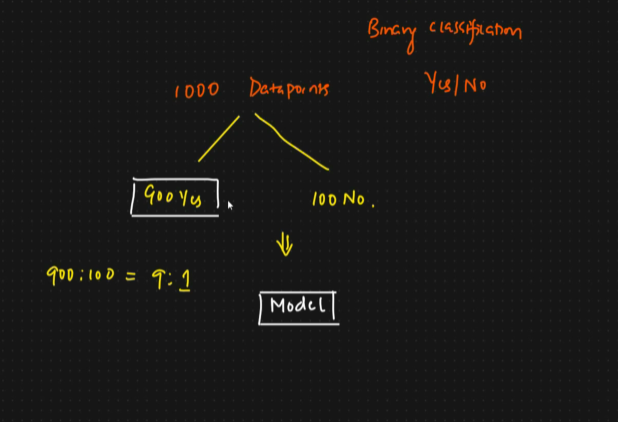

> Ypur model will be biased to the dataset with 900 yes , so this is called imbalaced Dataset

>> We need to make both the dataPoints yes/no equal , so that there is no biasing

# Two Methods we will be using :
    1. UP Sampling (inc. the DataSets)
    2. Down Sampling (reduce the datasets)

    


In [11]:
import numpy as np
import pandas as pd 

# Set the random seed for reproducibility
np.random.seed(123)


# Create a sample DataFrame with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [12]:
n_class_0, n_class_1

(900, 100)

In [13]:
# Create my dataframe with imbalanced dataset

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})
    

In [14]:
df = pd.concat([class_0, class_1]).reset_index(drop=True)

In [16]:
## UPSampling 
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [17]:
## UPSampling the minority class

df_minority=df[df['target'] == 1]
df_majority=df[df['target'] == 0]


In [19]:
from sklearn.utils import resample # Basicaly create a new sample of the minority class with replacement to match the size of the majority class.

df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42) # Upsample the minority class

In [20]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,-0.874146,-0.156083,1
992,0.196570,-0.602575,1
914,-0.067830,0.998053,1
971,0.272825,1.034197,1
960,0.870056,-0.449515,1


In [23]:
df_UPScaled = pd.concat([df_majority, df_minority_upsampled])
df_UPScaled['target'].value_counts()


target
0    900
1    900
Name: count, dtype: int64

In [24]:
# DOWNSampling the majority class

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

df = pd.concat([class_0, class_1]).reset_index(drop=True)


In [ ]:
## DOWNSampling the majority class

df_minority=df[df['target'] == 1]
df_majority=df[df['target'] == 0]


In [26]:
from sklearn.utils import resample
df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42) # Downsample the majority class
df_DOWNScaled = pd.concat([df_minority, df_majority_downsampled])
df_DOWNScaled['target'].value_counts()


target
1    100
0    100
Name: count, dtype: int64

In [29]:
df_DOWNScaled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

In [ ]:
# DownSampling will loss so much data and there will be less data to train the model. So, it is better to use UpSampling technique.